In [1]:
# Always start by importing tools and loading raw data
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the ORIGINAL raw file — we will NOT edit this
df = pd.read_csv('../data/raw/zomato.csv', encoding='latin-1')

In [3]:
# Make a working COPY so raw data stays safe
df_clean = df.copy()

print(f"Rows: {df_clean.shape[0]}, Columns: {df_clean.shape[1]}")

Rows: 51717, Columns: 17


In [4]:
print(df_clean['rate'])

0         4.1/5
1         4.1/5
2         3.8/5
3         3.7/5
4         3.8/5
          ...  
51712    3.6 /5
51713       NaN
51714       NaN
51715    4.3 /5
51716    3.4 /5
Name: rate, Length: 51717, dtype: object


In [5]:
# Problem: rate looks like "4.1/5" or "NEW" or "-" — not a number
print(df_clean['rate'].unique()[:10])  # See what values exist

['4.1/5' '3.8/5' '3.7/5' '3.6/5' '4.6/5' '4.0/5' '4.2/5' '3.9/5' '3.1/5'
 '3.0/5']


In [6]:
# Step 1: Replace non-numeric junk with NaN (missing value marker)
df_clean['rate'] = df_clean['rate'].replace('NEW', pd.NaT)
df_clean['rate'] = df_clean['rate'].replace('-', pd.NaT)

In [7]:
# Step 2: Remove the "/5" part from strings like "4.1/5"
# str.split('/') splits "4.1/5" into ["4.1", "5"]
# [0] takes the first part → "4.1"
df_clean['rate'] = df_clean['rate'].astype(str).str.split('/').str[0]

In [8]:
# Step 3: Convert to actual decimal numbers
df_clean['rate'] = pd.to_numeric(df_clean['rate'], errors='coerce')
# errors='coerce' turns anything unparseable into NaN

In [9]:
# Step 4: Fill missing ratings with the column average
avg_rating = df_clean['rate'].mean()
df_clean['rate'] = df_clean['rate'].fillna(avg_rating)

print(f"Average rating: {avg_rating:.2f}")
print(df_clean['rate'].describe())

Average rating: 3.70
count    51717.000000
mean         3.700449
std          0.395391
min          1.800000
25%          3.500000
50%          3.700449
75%          3.900000
max          4.900000
Name: rate, dtype: float64


In [10]:
# Column: 'approx_cost(for two people)'
# Problem: values like "800" but some have commas: "1,500"
print(df_clean['approx_cost(for two people)'].unique()[:10])

# Remove commas from strings like "1,500" → "1500"
df_clean['approx_cost(for two people)'] = (
    df_clean['approx_cost(for two people)']
    .astype(str)
    .str.replace(',', '')  # delete commas
)

# Convert to number
df_clean['approx_cost(for two people)'] = pd.to_numeric(
    df_clean['approx_cost(for two people)'], errors='coerce'
)

# Fill missing with median (median is better than mean for cost)
# because a few very expensive restaurants would skew the mean
median_cost = df_clean['approx_cost(for two people)'].median()
df_clean['approx_cost(for two people)'] = (
    df_clean['approx_cost(for two people)'].fillna(median_cost)
)

print(f"Median cost for two: ₹{median_cost}")

['800' '300' '600' '700' '550' '500' '450' '650' '400' '900']
Median cost for two: ₹400.0


In [11]:
# Check for duplicate restaurant entries
print(f"Before: {len(df_clean)} rows")
df_clean = df_clean.drop_duplicates()
print(f"After:  {len(df_clean)} rows")

# Rename the long cost column to something easier to type
df_clean = df_clean.rename(columns={
    'approx_cost(for two people)': 'cost_for_two',
    'listed_in(type)': 'meal_type',
    'listed_in(city)': 'city'
})

# Confirm new column names
print(df_clean.columns.tolist())

Before: 51717 rows
After:  51717 rows
['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes', 'phone', 'location', 'rest_type', 'dish_liked', 'cuisines', 'cost_for_two', 'reviews_list', 'menu_item', 'meal_type', 'city']


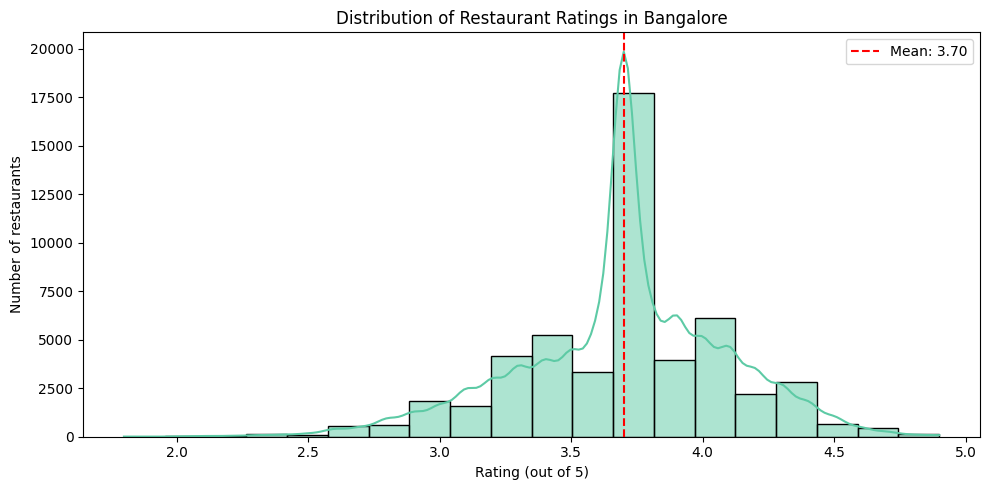

Most restaurants rated between 3.5 and 4.0


In [12]:
# Now that rate is a clean number, we can visualize it
plt.figure(figsize=(10, 5))

sns.histplot(
    df_clean['rate'],   # column to plot
    bins=20,            # split into 20 bars
    kde=True,           # draw smooth curve on top
    color='#5DCAA5'     # teal color
)

plt.title('Distribution of Restaurant Ratings in Bangalore')
plt.xlabel('Rating (out of 5)')
plt.ylabel('Number of restaurants')
plt.axvline(df_clean['rate'].mean(), color='red',
            linestyle='--', label=f"Mean: {df_clean['rate'].mean():.2f}")
plt.legend()
plt.tight_layout()
plt.savefig('../visuals/charts/rating_distribution.png')
plt.show()

# What does this tell us?
print(f"Most restaurants rated between 3.5 and 4.0")

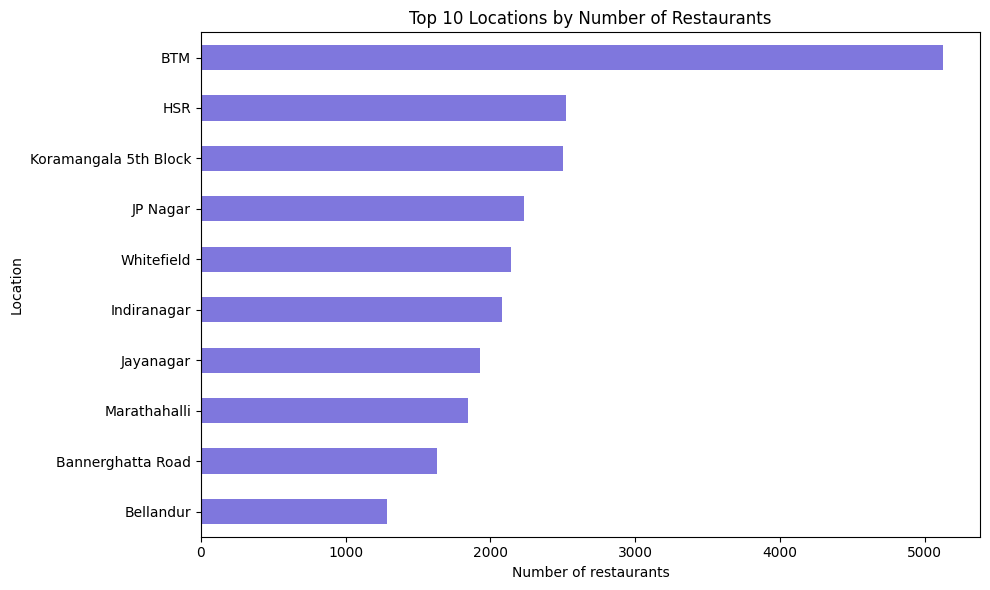

In [13]:
# Count restaurants per location, take top 10
top_locations = df_clean['location'].value_counts().head(10)

plt.figure(figsize=(10, 6))

# barh = horizontal bar chart (easier to read long location names)
top_locations.sort_values().plot(
    kind='barh',
    color='#7F77DD'   # purple
)

plt.title('Top 10 Locations by Number of Restaurants')
plt.xlabel('Number of restaurants')
plt.ylabel('Location')
plt.tight_layout()
plt.savefig('../visuals/charts/top_locations.png')
plt.show()

In [17]:
# Save cleaned dataframe as a new CSV
# This is what you'll use in all future notebooks
df_clean.to_csv('../data/cleaned/zomato_cleaned.csv', index=False)
# index=False means don't write the row numbers as a column

print(f"Saved! Shape: {df_clean.shape}")
print(f"Columns: {list(df_clean.columns)}")

# Quick final check — no missing values in key columns
print("\nMissing values in key columns:")
print(df_clean[['rate', 'cost_for_two', 'location', 'cuisines']].isnull().sum())

Saved! Shape: (51717, 17)
Columns: ['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes', 'phone', 'location', 'rest_type', 'dish_liked', 'cuisines', 'cost_for_two', 'reviews_list', 'menu_item', 'meal_type', 'city']

Missing values in key columns:
rate             0
cost_for_two     0
location        21
cuisines        45
dtype: int64
